In [10]:
import mesa
from mesa.discrete_space import OrthogonalVonNeumannGrid, FixedAgent

## Define Tree Cell Agent
An agent can have four possible conditions:
- **Fine**:
- **On Fire**: 
- **Burned Out**:
- **Wet**: 

In [11]:
class TreeCell(FixedAgent):
    """A tree cell.

    Attributes:
        condition: Can be "Fine", "On Fire", "Burned Out" or "Wet"

    """
    def __init__(self, model, cell, wet_probability=0.1):
        "create a new tree "
        super().__init__(model)
        self.condition = "Fine"
        self.cell = cell
        #generate the wet tree according to the probability
        if(self.random.random() < wet_probability):
            self.condition = "Wet"

    def step(self):
        """
        If the tree is on fire, spread it to fine trees nearby.
        The spread of fire can only in four direction(follow the VonNeumannGrid)
        
        """
        if self.condition == "On Fire":
            for neighbor in self.cell.neighborhood.agents:
                if neighbor.condition == "Fine":
                    neighbor.condition = "On Fire"
            self.condition = "Burned Out"

## ForestFire Model
- Add fire wall: `firebreak_column`: 


In [12]:
class ForestFire(mesa.Model):
    """Simple Forest Fire model with wet trees and Von Neumann neighborhood."""
    def __init__(self, width=100, height=100, density=0.65, 
                 wet_probability=0.1, firebreak_column=5, rng=None):
        super().__init__(rng=rng)

        # Set up model objects

        self.grid = OrthogonalVonNeumannGrid((width, height), capacity=1, random=self.random)
        self.datacollector = mesa.DataCollector(
            {
                "Fine": lambda m: self.count_type(m, "Fine"),
                "On Fire": lambda m: self.count_type(m, "On Fire"),
                "Burned Out": lambda m: self.count_type(m, "Burned Out"),
                "Wet": lambda m: self.count_type(m, "Wet")
            }
        )

    # Place a tree in each cell with Prob = density
        for cell in self.grid.all_cells:
            # Ignore the column with fire break wall 
            if cell.coordinate[0] == firebreak_column:
                continue
            if self.random.random() < density:
                # Create a tree
                new_tree = TreeCell(self, cell, wet_probability)
                # Set all trees in the first column on fire.
                if cell.coordinate[0] == 0:
                    # Only fire the tree without wet condition.
                    if new_tree.condition != "Wet":
                            new_tree.condition = "On Fire"

        self.running = True
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        self.agents.shuffle_do("step")
        # collect data
        self.datacollector.collect(self)

        # Halt if no more fire
        if self.count_type(self, "On Fire") == 0:
            self.running = False

    @staticmethod
    def count_type(model, tree_condition):
        """Helper method to count trees in a given condition in a given model."""
        return len(model.agents.select(lambda x: x.condition == tree_condition))

In [13]:
model = ForestFire(width=50, height=50, density=0.65, wet_probability=0.1, firebreak_column=25)
model.run_for(50)
print("Fine:", ForestFire.count_type(model, "Fine"))
print("Burned Out:", ForestFire.count_type(model, "Burned Out"))
print("Wet:", ForestFire.count_type(model, "Wet"))
print("On Fire:", ForestFire.count_type(model, "On Fire"))

Fine: 887
Burned Out: 590
Wet: 150
On Fire: 0


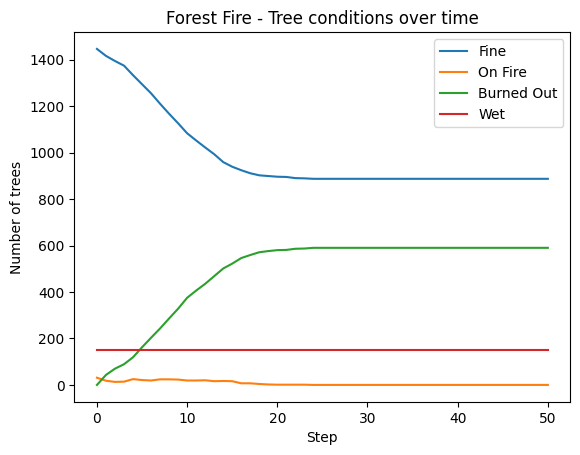

In [14]:
import matplotlib.pyplot as plt

data = model.datacollector.get_model_vars_dataframe()
data.plot()
plt.title("Forest Fire - Tree conditions over time")
plt.xlabel("Step")
plt.ylabel("Number of trees")
plt.show()